In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from kloppy import metrica
import numpy as np

In [ ]:
dataset = metrica.load_tracking_csv(
    home_data="https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Home_Team.csv",
    away_data="https://raw.githubusercontent.com/metrica-sports/sample-data/master/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv",
    # Optional arguments
    #sample_rate=1 / 5,
    limit=1000,
    coordinates="statsbomb",
)

In [ ]:
# 2. Transforma o objeto do Kloppy em um DataFrame do Pandas
df_tracking = dataset.to_pandas()

# 3. CORREÇÃO: Filtrar para garantir que pegamos um frame com dados reais de jogo
# Remove as linhas iniciais onde a bola ou jogadores ainda não foram capturados
df_limpo = df_tracking.dropna(subset=['ball_x', 'ball_y', 'home_11_x'])

/tmp/ipykernel_12669/3387695487.py:2: DeprecationWarning: Call to deprecated function to_pandas (to_pandas will be removed in the future. Please use to_df instead.).
  df_tracking = dataset.to_pandas()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Plota 1 Frame

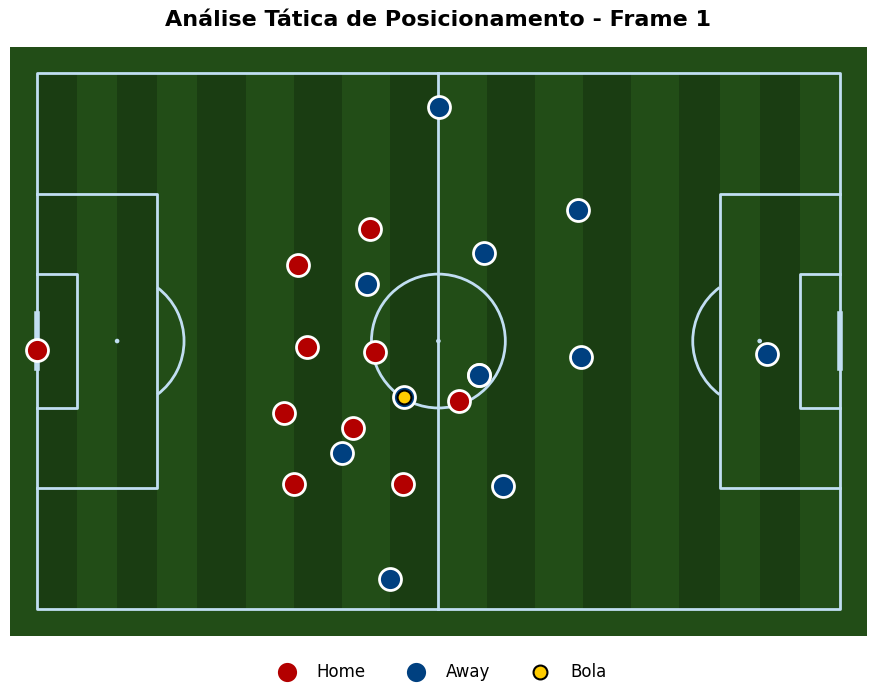

In [ ]:
# Definimos o frame alvo uma única vez de forma segura
frame_alvo = df_limpo.iloc[0]
id_do_frame_real = frame_alvo['frame_id']

# 4. Separar as coordenadas X e Y garantindo que ignoramos valores nulos (not np.isnan)
home_x = [frame_alvo[col] for col in df_tracking.columns if 'home_' in col and col.endswith('_x') and not np.isnan(frame_alvo[col])]
home_y = [frame_alvo[col] for col in df_tracking.columns if 'home_' in col and col.endswith('_y') and not np.isnan(frame_alvo[col])]

away_x = [frame_alvo[col] for col in df_tracking.columns if 'away_' in col and col.endswith('_x') and not np.isnan(frame_alvo[col])]
away_y = [frame_alvo[col] for col in df_tracking.columns if 'away_' in col and col.endswith('_y') and not np.isnan(frame_alvo[col])]

ball_x = frame_alvo['ball_x']
ball_y = frame_alvo['ball_y']

# 5. Configurar o campo de futebol usando o mplsoccer (Sua configuração excelente)
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#224d17',       # Verde gramado escuro profissional
    line_color='#c1def2',        # Linhas brancas/azuladas limpas
    stripe=True,                 # Adiciona as faixas verticais de corte do gramado
    stripe_color='#1a3d12'       # Tom das faixas do gramado
)

fig, ax = pitch.draw(figsize=(10, 7))

# 6. Plotar os jogadores e a bola usando as coordenadas filtradas
pitch.scatter(home_x, home_y, ax=ax, color='#b30000', edgecolors='white', s=250, linewidth=2, zorder=3, label='Home')
pitch.scatter(away_x, away_y, ax=ax, color='#004080', edgecolors='white', s=250, linewidth=2, zorder=3, label='Away')
pitch.scatter(ball_x, ball_y, ax=ax, color='#ffcc00', edgecolors='black', s=100, linewidth=1.5, zorder=4, label='Bola')

# 7. Títulos e Legendas Estilizados (Usando o ID correto do frame plotado)
plt.title(f"Análise Tática de Posicionamento - Frame {int(id_do_frame_real)}",
          fontsize=16, color='black', weight='bold', pad=15)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02),
           bbox_transform=ax.transAxes, ncol=3, fontsize=12, frameon=False)

plt.show()

Plota outro frame

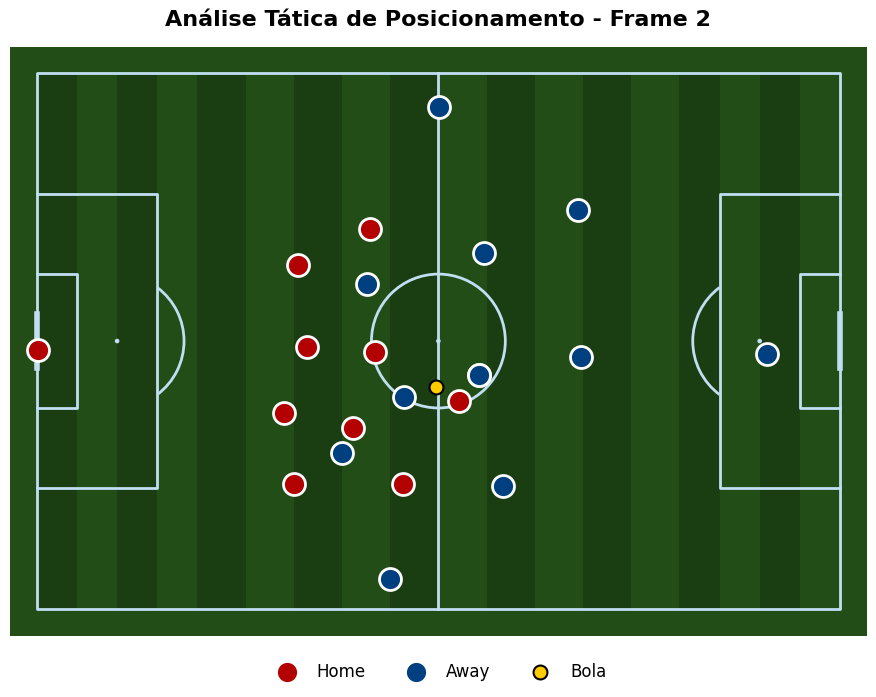

In [ ]:
# Definimos o frame alvo uma única vez de forma segura
frame_alvo = df_limpo.iloc[1]
id_do_frame_real = frame_alvo['frame_id']

# 4. Separar as coordenadas X e Y garantindo que ignoramos valores nulos (not np.isnan)
home_x = [frame_alvo[col] for col in df_tracking.columns if 'home_' in col and col.endswith('_x') and not np.isnan(frame_alvo[col])]
home_y = [frame_alvo[col] for col in df_tracking.columns if 'home_' in col and col.endswith('_y') and not np.isnan(frame_alvo[col])]

away_x = [frame_alvo[col] for col in df_tracking.columns if 'away_' in col and col.endswith('_x') and not np.isnan(frame_alvo[col])]
away_y = [frame_alvo[col] for col in df_tracking.columns if 'away_' in col and col.endswith('_y') and not np.isnan(frame_alvo[col])]

ball_x = frame_alvo['ball_x']
ball_y = frame_alvo['ball_y']

# 5. Configurar o campo de futebol usando o mplsoccer (Sua configuração excelente)
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#224d17',       # Verde gramado escuro profissional
    line_color='#c1def2',        # Linhas brancas/azuladas limpas
    stripe=True,                 # Adiciona as faixas verticais de corte do gramado
    stripe_color='#1a3d12'       # Tom das faixas do gramado
)

fig, ax = pitch.draw(figsize=(10, 7))

# 6. Plotar os jogadores e a bola usando as coordenadas filtradas
pitch.scatter(home_x, home_y, ax=ax, color='#b30000', edgecolors='white', s=250, linewidth=2, zorder=3, label='Home')
pitch.scatter(away_x, away_y, ax=ax, color='#004080', edgecolors='white', s=250, linewidth=2, zorder=3, label='Away')
pitch.scatter(ball_x, ball_y, ax=ax, color='#ffcc00', edgecolors='black', s=100, linewidth=1.5, zorder=4, label='Bola')

# 7. Títulos e Legendas Estilizados (Usando o ID correto do frame plotado)
plt.title(f"Análise Tática de Posicionamento - Frame {int(id_do_frame_real)}",
          fontsize=16, color='black', weight='bold', pad=15)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02),
           bbox_transform=ax.transAxes, ncol=3, fontsize=12, frameon=False)

plt.show()

Mais um frame

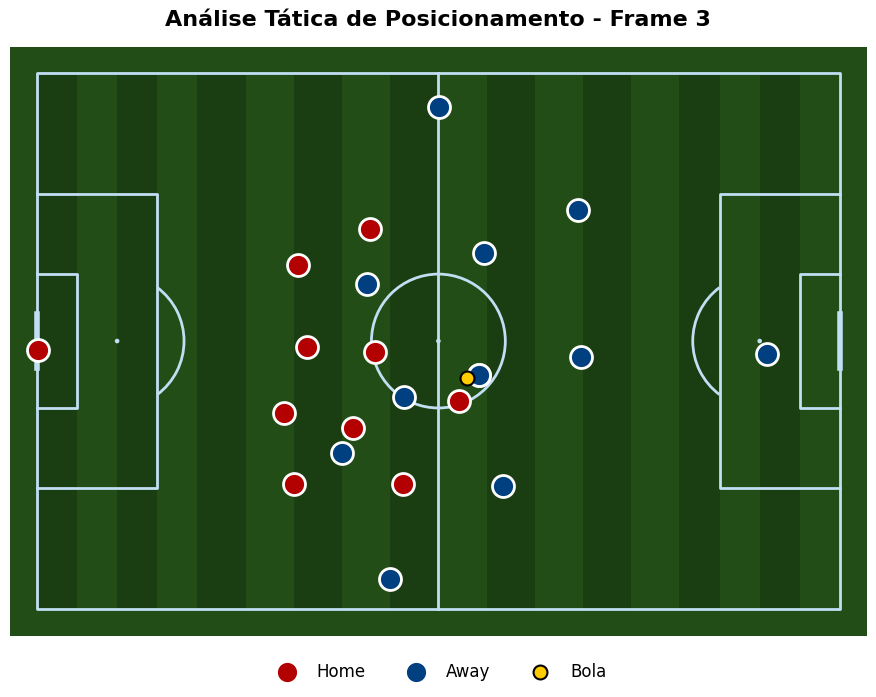

In [ ]:
# Definimos o frame alvo uma única vez de forma segura
frame_alvo = df_limpo.iloc[2]
id_do_frame_real = frame_alvo['frame_id']

# 4. Separar as coordenadas X e Y garantindo que ignoramos valores nulos (not np.isnan)
home_x = [frame_alvo[col] for col in df_tracking.columns if 'home_' in col and col.endswith('_x') and not np.isnan(frame_alvo[col])]
home_y = [frame_alvo[col] for col in df_tracking.columns if 'home_' in col and col.endswith('_y') and not np.isnan(frame_alvo[col])]

away_x = [frame_alvo[col] for col in df_tracking.columns if 'away_' in col and col.endswith('_x') and not np.isnan(frame_alvo[col])]
away_y = [frame_alvo[col] for col in df_tracking.columns if 'away_' in col and col.endswith('_y') and not np.isnan(frame_alvo[col])]

ball_x = frame_alvo['ball_x']
ball_y = frame_alvo['ball_y']

# 5. Configurar o campo de futebol usando o mplsoccer (Sua configuração excelente)
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#224d17',       # Verde gramado escuro profissional
    line_color='#c1def2',        # Linhas brancas/azuladas limpas
    stripe=True,                 # Adiciona as faixas verticais de corte do gramado
    stripe_color='#1a3d12'       # Tom das faixas do gramado
)

fig, ax = pitch.draw(figsize=(10, 7))

# 6. Plotar os jogadores e a bola usando as coordenadas filtradas
pitch.scatter(home_x, home_y, ax=ax, color='#b30000', edgecolors='white', s=250, linewidth=2, zorder=3, label='Home')
pitch.scatter(away_x, away_y, ax=ax, color='#004080', edgecolors='white', s=250, linewidth=2, zorder=3, label='Away')
pitch.scatter(ball_x, ball_y, ax=ax, color='#ffcc00', edgecolors='black', s=100, linewidth=1.5, zorder=4, label='Bola')

# 7. Títulos e Legendas Estilizados (Usando o ID correto do frame plotado)
plt.title(f"Análise Tática de Posicionamento - Frame {int(id_do_frame_real)}",
          fontsize=16, color='black', weight='bold', pad=15)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02),
           bbox_transform=ax.transAxes, ncol=3, fontsize=12, frameon=False)

plt.show()

Dataset

In [ ]:
print(df_tracking)

     period_id              timestamp  frame_id ball_state  \
0            1 0 days 00:00:00.040000         1       None   
1            1 0 days 00:00:00.080000         2       None   
2            1 0 days 00:00:00.120000         3       None   
3            1 0 days 00:00:00.160000         4       None   
4            1 0 days 00:00:00.200000         5       None   
..         ...                    ...       ...        ...   
994          1 0 days 00:00:39.800000       995       None   
995          1 0 days 00:00:39.840000       996       None   
996          1 0 days 00:00:39.880000       997       None   
997          1 0 days 00:00:39.920000       998       None   
998          1 0 days 00:00:39.960000       999       None   

    ball_owning_team_id     ball_x     ball_y ball_z ball_speed  home_11_x  \
0                  None  54.803934  48.383142   None       None   0.093927   
1                  None  59.592623  46.938822   None       None   0.109964   
2                  No

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
df_tracking.head()

,period_id,timestamp,frame_id,ball_state,ball_owning_team_id,ball_x,ball_y,ball_z,ball_speed,home_11_x,...,away_22_d,away_22_s,away_23_x,away_23_y,away_23_d,away_23_s,away_24_x,away_24_y,away_24_d,away_24_s
0,1,0 days 00:00:00.040000,1,None,None,54.803934,48.383142,None,None,0.093927,...,None,None,52.762459,75.576266,None,None,45.624578,56.784975,None,None
1,1,0 days 00:00:00.080000,2,None,None,59.592623,46.938822,None,None,0.109964,...,None,None,52.762459,75.576266,None,None,45.624578,56.784975,None,None
2,1,0 days 00:00:00.120000,3,None,None,64.264262,45.529367,None,None,0.130582,...,None,None,52.762459,75.576266,None,None,45.624578,56.784975,None,None
3,1,0 days 00:00:00.160000,4,None,None,66.134754,45.770458,None,None,0.138600,...,None,None,52.706230,75.544428,None,None,45.527000,56.718211,None,None
4,1,0 days 00:00:00.200000,5,None,None,66.325246,47.002618,None,None,0.147764,...,None,None,52.632787,75.598376,None,None,45.409147,56.666284,None,None


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
